# 03 Resultados Finales

Este notebook consolida la etapa final del proyecto:
- carga resultados de ACO y GA
- compara ambos metodos
- selecciona la mejor solucion
- expande el tour TSP a una ruta real sobre el grafo
- genera visualizaciones y GIF
- exporta artefactos listos para entrega y para la web


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

ROOT

WindowsPath('C:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/2. optimizacion_combinatoria')

In [2]:
import json
import pandas as pd
from IPython.display import Image, SVG, Markdown, display


from src.core_paths import VIS_OUTPUT_DIR, WEB_OUTPUT_DIR
from src.core_resultados import (
    build_comparison,
    expand_best_tour,
    export_final_bundle,
    export_visual_artifacts,
    generate_solution_gif,
    load_method_results,
    pick_best_result,
)


In [3]:
def load_json(path):
    with Path(path).open('r', encoding='utf-8') as handle:
        return json.load(handle)

def show_table(title, df, columns=None, sort_by=None, ascending=True, precision=4):
    table = df.copy()
    if columns is not None:
        table = table.reindex(columns=columns)
    if sort_by is not None:
        table = table.sort_values(sort_by, ascending=ascending).reset_index(drop=True)
    display(Markdown(f'### {title}'))
    display(table.fillna('-').style.format(precision=precision))


## 1. Cargar resultados de optimizacion

Se recuperan los resultados guardados por el notebook `02_optimizacion.ipynb`.

In [4]:
aco_result, ga_result = load_method_results()
print('Costo ACO:', aco_result['mejor_costo_tour'])
print('Costo GA:', ga_result['mejor_costo_tour'])

Costo ACO: 4471.569332
Costo GA: 4303.602999


## 2. Comparacion de metodos

Se construye una comparacion numerica entre ACO y GA y se identifica automaticamente el mejor metodo.

In [5]:
comparison = build_comparison(aco_result, ga_result)
best_method, best_result = pick_best_result(aco_result, ga_result)
comparison

{'mejor_metodo': 'GA',
 'costo_aco': 4471.569332,
 'costo_ga': 4303.602999,
 'mejor_costo': 4303.602999,
 'diferencia_absoluta': 167.966333,
 'diferencia_relativa_pct': 3.7563}

In [6]:
pd.DataFrame([
    {'metodo': 'ACO', 'mejor_costo': aco_result['mejor_costo_tour']},
    {'metodo': 'GA', 'mejor_costo': ga_result['mejor_costo_tour']},
]).sort_values('mejor_costo').reset_index(drop=True)

,metodo,mejor_costo
0,GA,4303.602999
1,ACO,4471.569332


## 3. Mejor solucion y tour expandido

El mejor tour sobre la matriz TSP se expande a la ruta real sobre el grafo usando la matriz de siguiente salto.

In [7]:
expanded = expand_best_tour(best_result)
print('Metodo ganador:', best_method)
print('Costo mejor tour:', best_result['mejor_costo_tour'])
print('Saltos TSP:', expanded['n_saltos_tsp'])
print('Saltos reales:', expanded['n_saltos_reales'])

Metodo ganador: GA
Costo mejor tour: 4303.602999
Saltos TSP: 96
Saltos reales: 109


In [8]:
pd.DataFrame(expanded['tramos_expandidos']).head()

,origen_indice,destino_indice,ruta_indices,costo_tramo,ruta_nombres
0,0,4,"[0, 74, 73, 38, 4]",147.731334,"[Bourg-en-Bresse, Annecy, Chambéry, Grenoble, ..."
1,4,19,"[4, 3, 5, 19]",296.891000,"[Gap, Digne-les-Bains, Nice, Ajaccio]"
2,19,20,"[19, 20]",75.034333,"[Ajaccio, Bastia]"
3,20,5,"[20, 5]",219.296333,"[Bastia, Nice]"
4,5,3,"[5, 3]",70.050000,"[Nice, Digne-les-Bains]"


## 4. Visualizaciones finales

Se genera una visualizacion SVG de la mejor ruta y una visualizacion SVG del historial de convergencia del metodo ganador.

In [9]:
visuals = export_visual_artifacts(best_result, best_method)
visuals

{'route_svg_path': WindowsPath('C:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/2. optimizacion_combinatoria/outputs/visualizaciones/visualizacion_mejor_solucion.svg'),
 'history_svg_path': WindowsPath('C:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/2. optimizacion_combinatoria/outputs/visualizaciones/convergencia_ga.svg')}

### Visualizacion de la mejor ruta

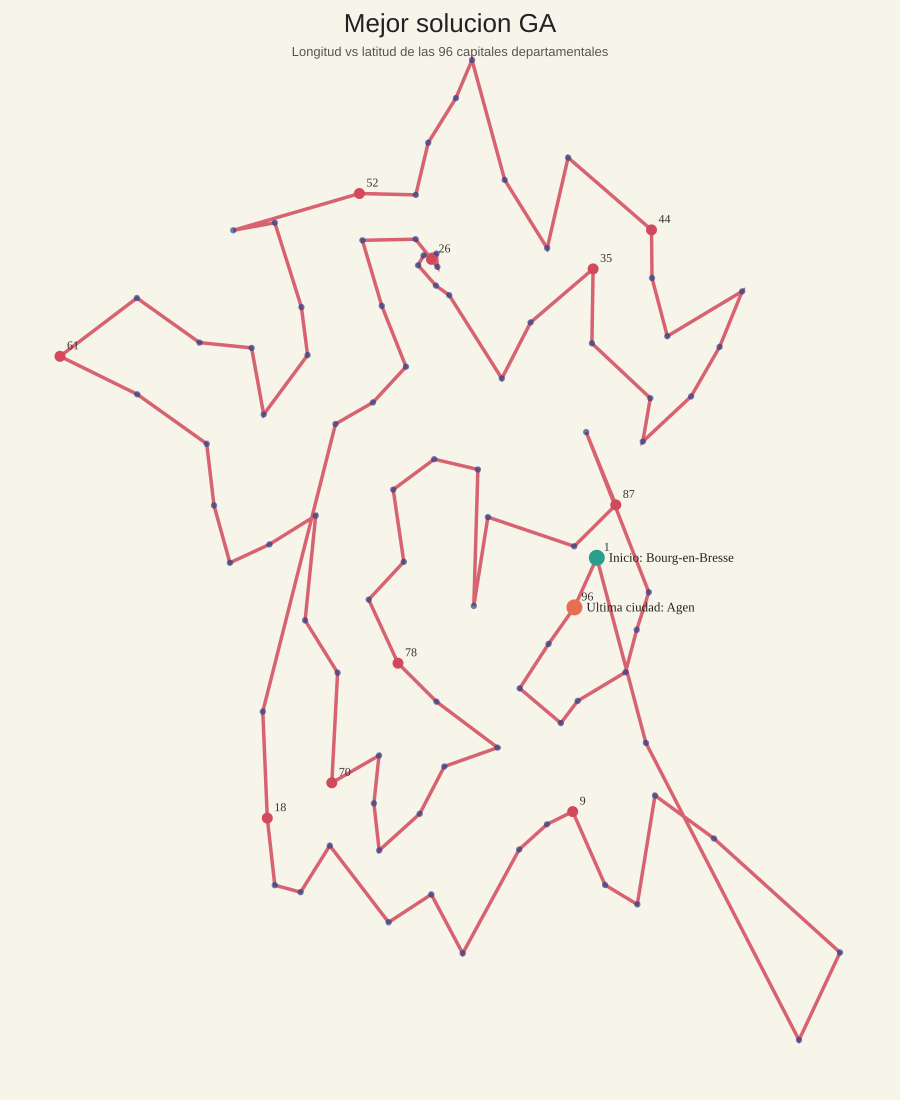

### Convergencia del metodo ganador

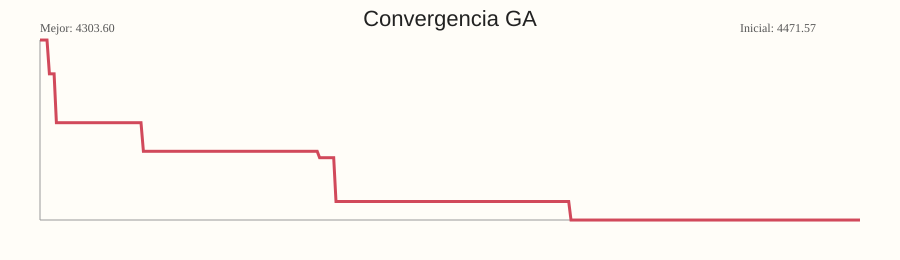

In [10]:
display(Markdown('### Visualizacion de la mejor ruta'))
display(SVG(filename=str(visuals['route_svg_path'])))

display(Markdown('### Convergencia del metodo ganador'))
display(SVG(filename=str(visuals['history_svg_path'])))

## 5. GIF de la mejor solucion

La ruta final se anima para facilitar la comunicacion del resultado en la entrega y en la web.

In [11]:
gif_info = generate_solution_gif(best_method, best_result)
gif_info['gif_summary']

{'metodo_ganador': 'GA',
 'mejor_costo_tour': 4303.602999,
 'frames': 104,
 'archivo_gif': 'C:\\Carlos\\Uni\\Algortimos\\trabajos\\trabajo_1\\trabajo_carlos\\2. optimizacion_combinatoria\\outputs\\visualizaciones\\mejor_solucion_combinatoria.gif',
 'formula_peso': 'peajes(euros) + gasolina(euros) + (tiempo(min)/60) * 12.02'}

### GIF de la mejor solucion

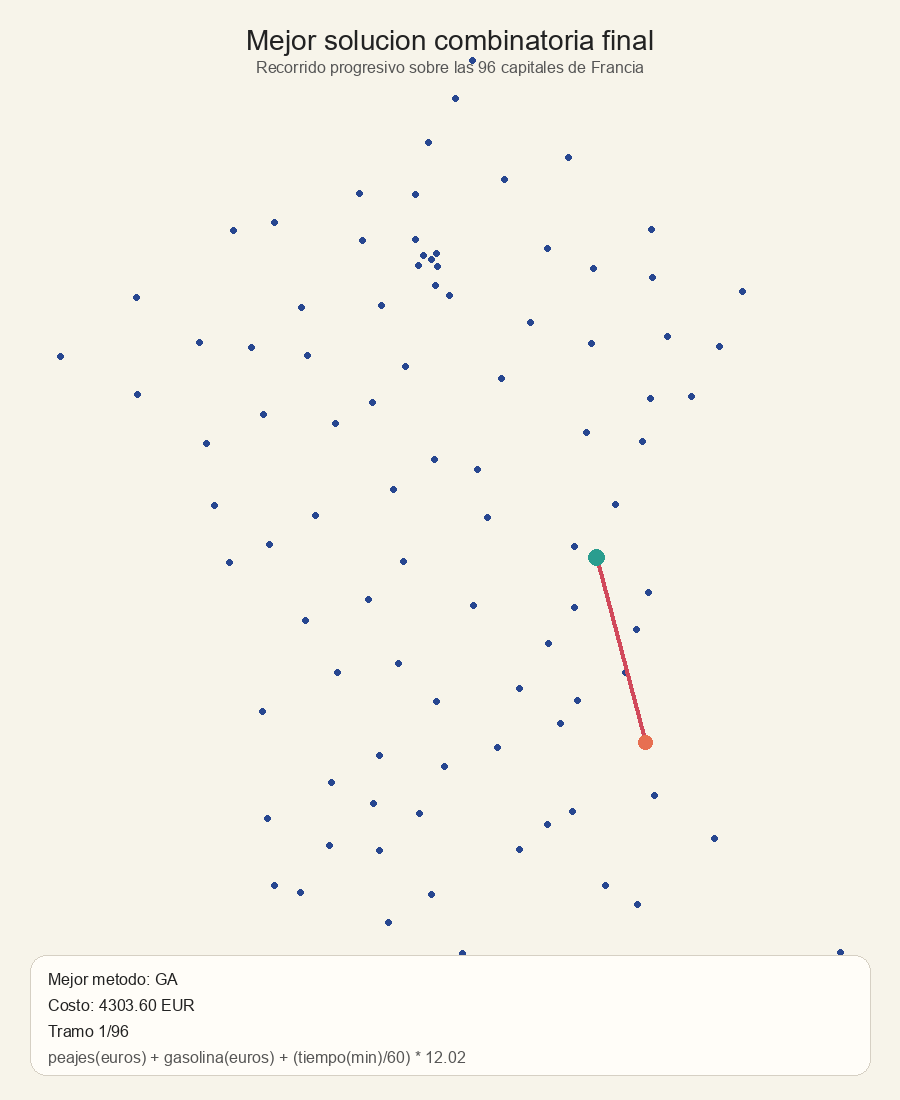

,metodo_ganador,mejor_costo_tour,frames,archivo_gif,formula_peso
0,GA,4303.602999,104,C:\Carlos\Uni\Algortimos\trabajos\trabajo_1\tr...,peajes(euros) + gasolina(euros) + (tiempo(min)...


In [12]:
display(Markdown('### GIF de la mejor solucion'))
display(Image(filename=str(gif_info['gif_path'])))
pd.DataFrame([gif_info['gif_summary']])

## 6. Bundle final para la web

Se exportan archivos JSON finales pensados para consumo directo desde una aplicacion web, sin recalcular el pipeline.

In [13]:
final_bundle = export_final_bundle(best_method, best_result, expanded, comparison)
final_bundle['web_summary']

{'metodo_ganador': 'GA',
 'mejor_costo_tour': 4303.602999,
 'n_ciudades': 96,
 'n_saltos_reales': 109,
 'formula_peso': 'peajes(euros) + gasolina(euros) + (tiempo(min)/60) * 12.02'}

In [14]:
comparison_json = load_json(final_bundle['comparison_path'])
best_result_json = load_json(final_bundle['best_result_path'])
expanded_route_json = load_json(final_bundle['expanded_route_path'])
web_summary_json = load_json(final_bundle['web_summary_path'])

In [15]:
df_comparacion_json = pd.json_normalize(comparison_json)
df_resumen_web_json = pd.json_normalize(web_summary_json)
df_mejor_resultado_json = pd.json_normalize({
    'metodo_ganador': best_method,
    'mejor_costo_tour': best_result_json.get('mejor_costo_tour'),
    'shape_matriz': best_result_json.get('shape_matriz'),
    'formula_peso': best_result_json.get('formula_peso'),
    'tarifa_vendedor_eur_h': best_result_json.get('tarifa_vendedor_eur_h'),
    'salario_referencia': best_result_json.get('salario_referencia'),
    'n_ciudades_tour': len(best_result_json.get('mejor_tour_indices_sin_cierre', [])),
    'n_puntos_historial': len(best_result_json.get('historial_mejor_costo', [])),
    'inicio_tour_nombres': ', '.join(best_result_json.get('mejor_tour_nombres', [])[:8]),
})

show_table('Resumen web', df_resumen_web_json)
show_table('Comparacion de metodos', df_comparacion_json)
show_table('Mejor resultado', df_mejor_resultado_json)

### Resumen web

,campo,valor
0,metodo_ganador,GA
1,mejor_costo_tour,4303.602999
2,n_ciudades,96
3,n_saltos_reales,109
4,formula_peso,peajes(euros) + gasolina(euros) + (tiempo(min)...


### Comparacion de metodos

,campo,valor
0,mejor_metodo,GA
1,costo_aco,4471.569332
2,costo_ga,4303.602999
3,mejor_costo,4303.602999
4,diferencia_absoluta,167.966333
5,diferencia_relativa_pct,3.7563


### Mejor resultado

,campo,valor
0,metodo_ganador,None
1,mejor_costo_tour,4303.602999
2,formula_peso,peajes(euros) + gasolina(euros) + (tiempo(min)...
3,shape_matriz,"[96, 96]"


In [16]:
df_tramos_expandidos = pd.DataFrame(expanded_route_json['tramos_expandidos'])
df_resumen_ruta_expandida = pd.DataFrame([{
    'saltos_tsp': expanded_route_json.get('n_saltos_tsp'),
    'saltos_reales': expanded_route_json.get('n_saltos_reales'),
    'costo_total_tour': expanded_route_json.get('costo_total_tour'),
    'n_tramos_expandidos': len(expanded_route_json.get('tramos_expandidos', [])),
    'inicio_ruta': expanded_route_json.get('recorrido_real_nombres', [None])[0],
    'fin_ruta': expanded_route_json.get('recorrido_real_nombres', [None])[-1],
}])

show_table('Resumen de la ruta expandida', df_resumen_ruta_expandida)
show_table('Ruta expandida por tramos (primeros 20)', df_tramos_expandidos.head(20))

### Vista previa de la ruta expandida

,origen_indice,destino_indice,ruta_indices,costo_tramo,ruta_nombres
0,0,4,"[0, 74, 73, 38, 4]",147.731334,"[Bourg-en-Bresse, Annecy, Chambéry, Grenoble, ..."
1,4,19,"[4, 3, 5, 19]",296.891000,"[Gap, Digne-les-Bains, Nice, Ajaccio]"
2,19,20,"[19, 20]",75.034333,"[Ajaccio, Bastia]"
3,20,5,"[20, 5]",219.296333,"[Bastia, Nice]"
4,5,3,"[5, 3]",70.050000,"[Nice, Digne-les-Bains]"
5,3,83,"[3, 83]",75.541667,"[Digne-les-Bains, Toulon]"
6,83,12,"[83, 12]",51.097000,"[Toulon, Marseille]"
7,12,84,"[12, 84]",30.518333,"[Marseille, Avignon]"
8,84,30,"[84, 30]",25.316667,"[Avignon, Nîmes]"
9,30,34,"[30, 34]",25.956333,"[Nîmes, Montpellier]"


In [17]:
show_table('Artefactos finales generados', pd.DataFrame([
    {
        'nombre': 'comparacion_metodos.json',
        'ruta': str(final_bundle['comparison_path']),
        'tipo': 'JSON',
        'proposito': 'Comparacion consolidada entre ACO y GA para consumo final y web.',
    },
    {
        'nombre': 'mejor_resultado.json',
        'ruta': str(final_bundle['best_result_path']),
        'tipo': 'JSON',
        'proposito': 'Resultado completo del metodo ganador con tour, costo e historial.',
    },
    {
        'nombre': 'mejor_ruta_expandida.json',
        'ruta': str(final_bundle['expanded_route_path']),
        'tipo': 'JSON',
        'proposito': 'Ruta real expandida sobre el grafo a partir del tour TSP ganador.',
    },
    {
        'nombre': 'resumen_web.json',
        'ruta': str(final_bundle['web_summary_path']),
        'tipo': 'JSON',
        'proposito': 'Resumen compacto listo para alimentar una interfaz web o demo.',
    },
    {
        'nombre': 'visualizacion_mejor_solucion.svg',
        'ruta': str(visuals['route_svg_path']),
        'tipo': 'SVG',
        'proposito': 'Visualizacion vectorial de la mejor ruta encontrada.',
    },
    {
        'nombre': 'convergencia.svg',
        'ruta': str(visuals['history_svg_path']),
        'tipo': 'SVG',
        'proposito': 'Grafica de convergencia del metodo ganador durante la optimizacion.',
    },
    {
        'nombre': 'mejor_solucion_combinatoria.gif',
        'ruta': str(gif_info['gif_path']),
        'tipo': 'GIF',
        'proposito': 'Animacion progresiva del recorrido final para entrega y presentacion.',
    },
]), columns=['nombre', 'ruta', 'tipo', 'proposito'])

,archivo,ruta
0,comparacion_metodos.json,C:\Carlos\Uni\Algortimos\trabajos\trabajo_1\tr...
1,mejor_resultado.json,C:\Carlos\Uni\Algortimos\trabajos\trabajo_1\tr...
2,mejor_ruta_expandida.json,C:\Carlos\Uni\Algortimos\trabajos\trabajo_1\tr...
3,resumen_web.json,C:\Carlos\Uni\Algortimos\trabajos\trabajo_1\tr...
4,visualizacion_mejor_solucion.svg,C:\Carlos\Uni\Algortimos\trabajos\trabajo_1\tr...
5,convergencia.svg,C:\Carlos\Uni\Algortimos\trabajos\trabajo_1\tr...
6,mejor_solucion_combinatoria.gif,C:\Carlos\Uni\Algortimos\trabajos\trabajo_1\tr...


## 7. Salida final

Al terminar este notebook quedan listos los artefactos finales en:
- `outputs/visualizaciones`
- `outputs/web`

Estos archivos pueden alimentar directamente la entrega escrita, una demo o una web.

In [18]:
print('Visualizaciones:', VIS_OUTPUT_DIR)
print('Bundle final web:', WEB_OUTPUT_DIR)

Visualizaciones: C:\Carlos\Uni\Algortimos\trabajos\trabajo_1\trabajo_carlos\2. optimizacion_combinatoria\outputs\visualizaciones
Bundle final web: C:\Carlos\Uni\Algortimos\trabajos\trabajo_1\trabajo_carlos\2. optimizacion_combinatoria\outputs\web
